In [1]:
from casatasks import *
import casatools
import os
import matplotlib.pyplot as plt

from casaplotms import plotms
from casaviewer.imview import imview
import glob
import numpy as np
msmd = casatools.msmetadata()
ms = casatools.ms()
tb = casatools.table()
import matplotlib as mpl


def compute_vis_restoring_beam(vis,
                               casa_path='casa'):
    """
    Compute the effective restoring beam of a visibility. 

    Note that this function uses the analysis utils function estimateSynthesizedBeam.
    For that, this function will generate a python script that will be excecuted with CASA
    using subprocess. 
    """
    
    import subprocess
    import os
    
    # Set the environment variable to use the 'Agg' backend for matplotlib
    os.environ['MPLBACKEND'] = 'Agg'
    
    # Define the content of the Python script
    script_content = f"""
import matplotlib
matplotlib.use('Agg')  # Use the 'Agg' backend for headless environments

import sys
sys.path.append('/media/sagauga/xfs_evo/GoogleDrive/GitHubUoM/morphen/morphen/analysis_scripts/')
import analysisUtils as au
effective_beam = au.estimateSynthesizedBeam('{vis}', useL80method=True, field='')
print(effective_beam)
    """
    
    # Write the content to compute_beam.py
    with open('compute_beam.py', 'w') as file:
        file.write(script_content)
    
    # Define the command to run the external script
    command = [
        casa_path, 
        '-nologger',
        '-c',
        'compute_beam.py'
    ]
    # Run the command and capture the output
    result = subprocess.run(command, capture_output=True, text=True)
    
    effective_beam = result.stdout.splitlines()[-1]
    print("Effective Beam:", effective_beam)
    return(effective_beam)


In [2]:
import sys
sys.path.append('../../../morphen/morphen/')
import mlibs as mlibs



                                                          ..___|**_
                                                  .|||||||||*+@+*__*++.
                                              _||||.           .*+;].,#_
                                         _|||*_                _    .@@@#@.
                                   _|||||_               .@##@#| _||_
       Morphen                |****_                   .@.,/\..@_.
                             #///#+++*|    .       .@@@;#.,.\@.
                              .||__|**|||||*||*+@#];_.  ;,;_
 Geferson Lucatelli                            +\*_.__|**#
                                              |..      .]]
                                               ;@       @.*.
                                                #|       _;]];|.
                                                 ]_          _+;]@.
                                                 _/_             |]\|    .  _
                                              ...._@* __ .

## e-MERLIN only imaging

In [7]:
n_subimages = 4
imsizex = int(1024*2)
imsizey = int(1024*2)
opt_args= "' -circular-beam '"
cell = '0.008asec'
# prefix = f"im_nc{n_subimages}_cb_bandwidth"
prefix = f"im_nc{n_subimages}_cb"
nsigma_automask = '4.0'
nsigma_autothreshold = '2.0'
uvtaper = ['']
vis_list = {
    'eM_C':   '/media/sagauga/void/astronomical-data/LIRGI_Sample_v2/IRAS23436+5257/eM_C/IRAS23436+5257_eM_C.ms',
}
for image_name in vis_list.keys():
    print(image_name)
    print(vis_list[image_name])
    mlibs.listobs(vis=vis_list[image_name],listfile=vis_list[image_name].replace('.ms','.listobs'),overwrite=True)

eM_C
/media/sagauga/void/astronomical-data/LIRGI_Sample_v2/IRAS23436+5257/eM_C/IRAS23436+5257_eM_C.ms


Imaging instrument/band eM_C
    > Visibility: /media/sagauga/void/astronomical-data/LIRGI_Sample_v2/IRAS23436+5257/eM_C/IRAS23436+5257_eM_C.ms
 >> Imaging script path: /media/sagauga/starbyte/cloud/SACO/GitHub/morphen/morphen
 >> Using 24 threads for processing. Total threads available: 24
 >> Using WSClean container: /media/sagauga/starbyte/cloud/SACO/GitHub/morphen/morphen/wsclean36_cpu_portable_emerlin.sif (from ph4ser module directory)
Using WSClean from singularity image:  /media/sagauga/starbyte/cloud/SACO/GitHub/morphen/morphen/wsclean36_cpu_portable_emerlin.sif
WSClean version from singularity image: 

WSClean version 3.6 (2025-02-07)
Git commit hash: v3.6
This software package is released under the GPL version 3.
Author: André Offringa (offringa@gmail.com).

EveryBeam is available.
IDG is available.
WGridder is available.
  1.0
Using mtmfs method.
im_nc4_cb_IRAS23436+5257_eM_C_2048x2048_am_4.0_at_2.0_0.008asec_multiscale__r1.0
 >> Using scratch directory for WSClean temporary

/media/sagauga/starbyte/cloud/SACO/GitHub/morphen/morphen/image_morphometry.py:7382: RuntimeWarning: invalid value encountered in divide
  y0peak, x0peak = nd.maximum_position((image / rr2))
findfont: Failed to find font weight medium for STIXGeneral, now using 400.


 ==>  Peak of Flux      = 0.408 +/- 0.037 [mJy/beam] (SNR=20.1)
 ==>  Snu (within mask) = 1.908 +/- 0.143 [mJy]
 ==>  Snu (image)       = 3.741 (no independent error estimate)
 ==>  R50               = 0.1190 +/- 0.0315 [arcsec]
 ==>  R50_major         = 0.1425 +/- 0.0377 [arcsec]  (q_eff=0.70)
 ==>  R95               = 0.2055 +/- 0.0503 [arcsec]
 ==>  R95_major         = 0.2461 +/- 0.0603 [arcsec]  (q_eff=0.70)


findfont: Failed to find font weight medium for STIXGeneral, now using 400.
findfont: Failed to find font weight medium for STIXGeneral, now using 400.
findfont: Failed to find font weight medium for STIXNonUnicode, now using 400.
findfont: Failed to find font weight medium for STIXNonUnicode, now using 400.
findfont: Failed to find font weight medium for STIXSizeOneSym, now using 400.
findfont: Failed to find font weight medium for STIXSizeTwoSym, now using 400.
findfont: Failed to find font weight medium for STIXSizeThreeSym, now using 400.
findfont: Failed to find font weight medium for STIXSizeFourSym, now using 400.
findfont: Failed to find font weight medium for STIXSizeFiveSym, now using 400.
findfont: Failed to find font weight medium for STIXGeneral, now using 400.


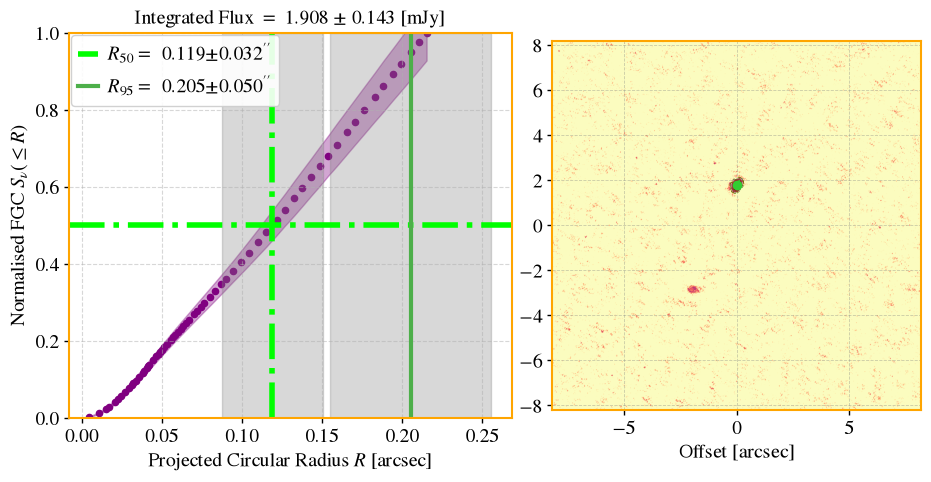

Using residual map as RMS estimator: /media/sagauga/void/astronomical-data/LIRGI_Sample_v2/IRAS23436+5257/eM_C/im_nc4_cb_IRAS23436+5257_eM_C_2048x2048_am_4.0_at_2.0_0.008asec_multiscale__r1.0-MFS-residual.fits


findfont: Failed to find font weight medium for STIXGeneral, now using 400.
findfont: Failed to find font weight medium for STIXGeneral, now using 400.


-----------------------------------------------------------------
Flux Density (systematic + noise*sqrt(N_beams) + residual):
  S_nu = 2.187 +/- 0.247 mJy
  Fractional error = 0.113
-----------------------------------------------------------------


/media/sagauga/starbyte/cloud/SACO/GitHub/morphen/morphen/image_morphometry.py:7382: RuntimeWarning: invalid value encountered in divide
  y0peak, x0peak = nd.maximum_position((image / rr2))


 ==>  Peak of Flux      = 0.546 +/- 0.049 [mJy/beam] (SNR=13.9)
 ==>  Snu (within mask) = 2.187 +/- 0.247 [mJy]
 ==>  Snu (image)       = 4.486 (no independent error estimate)
 ==>  R50               = 0.0853 +/- 0.0289 [arcsec]
 ==>  R50_major         = 0.1021 +/- 0.0346 [arcsec]  (q_eff=0.70)
 ==>  R95               = 0.1428 +/- 0.0516 [arcsec]
 ==>  R95_major         = 0.1710 +/- 0.0618 [arcsec]  (q_eff=0.70)
-----------------------------------------------------------------
Flux Density (systematic + noise*sqrt(N_beams) + residual):
  S_nu = 1.938 +/- 0.263 mJy
  Fractional error = 0.136
-----------------------------------------------------------------


...

/media/sagauga/starbyte/cloud/SACO/GitHub/morphen/morphen/image_morphometry.py:7382: RuntimeWarning: invalid value encountered in divide
  y0peak, x0peak = nd.maximum_position((image / rr2))


 ==>  Peak of Flux      = 0.331 +/- 0.059 [mJy/beam] (SNR=9.9)
 ==>  Snu (within mask) = 1.199 +/- 0.147 [mJy]
 ==>  Snu (image)       = 1.765 (no independent error estimate)
 ==>  R50               = 0.0618 +/- 0.0179 [arcsec]
 ==>  R50_major         = 0.0809 +/- 0.0235 [arcsec]  (q_eff=0.58)
 ==>  R95               = 0.1020 +/- 0.0449 [arcsec]
 ==>  R95_major         = 0.1335 +/- 0.0588 [arcsec]  (q_eff=0.58)
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         6.5589e+00                                    4.65e+00    
       1              2         5.2797e-01      6.03e+00       9.59e+00       5.10e+03    
       2              3         5.1491e-01      1.31e-02       6.06e+00       2.75e+00    
       3              4         6.2384e-02      4.53e-01       1.44e+00       2.83e+03    
       4              5         5.4836e-03      5.69e-02       1.32e+00       6.75e-02    
       5              6         1.6035e

100%|██████████| 5000/5000 [00:03<00:00, 1453.92it/s]


{'A1': {'best': 1.5879493123843849, 'lower_bound': 1.488595547511985, 'upper_bound': 1.6873680380637346, 'lower': 0.09935376487239989, 'upper': 0.09941872567934973}, 'alpha': {'best': -1.5594141030093343, 'lower_bound': -1.9421484823156232, 'upper_bound': -1.170818944636796, 'lower': 0.38273437930628895, 'upper': 0.3885951583725382}}


findfont: Failed to find font weight medium for STIXGeneral, now using 400.
findfont: Failed to find font weight medium for STIXGeneral, now using 400.


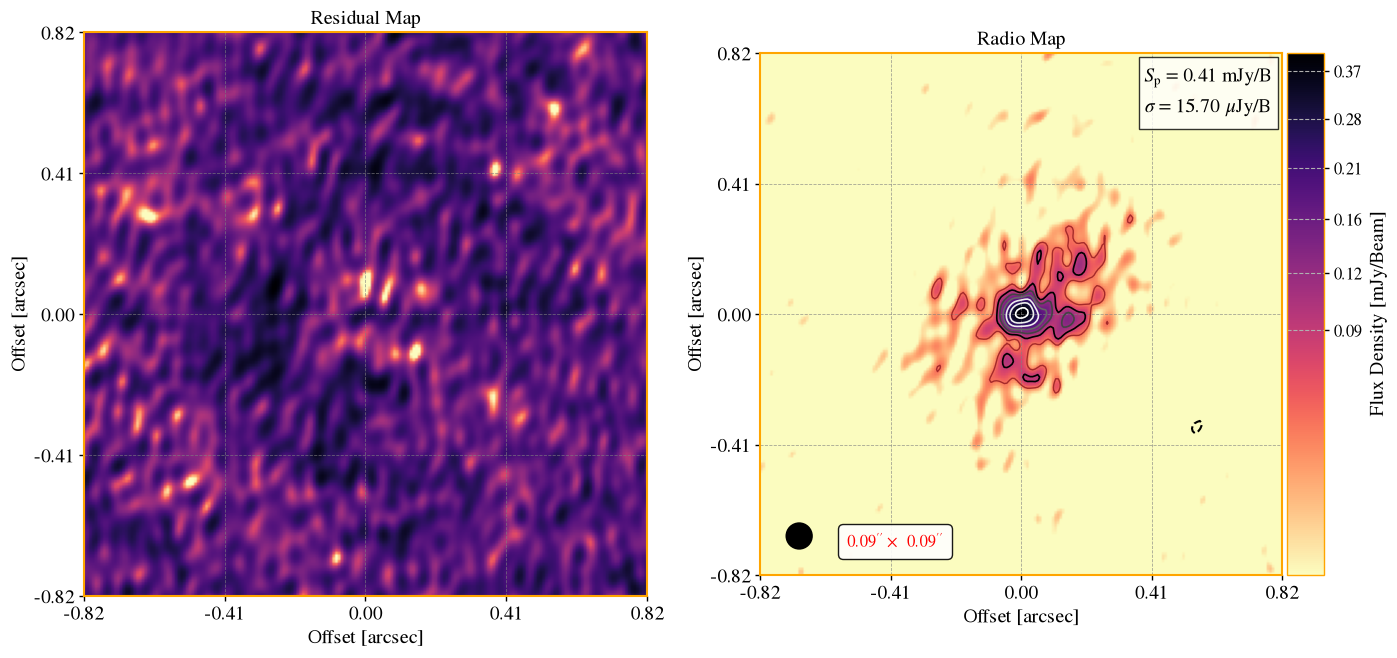

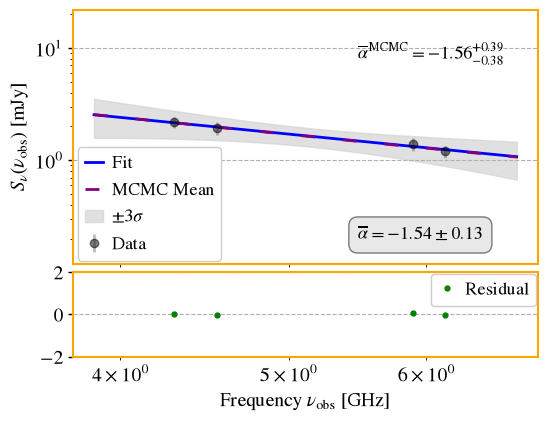

(100000, 2)


<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

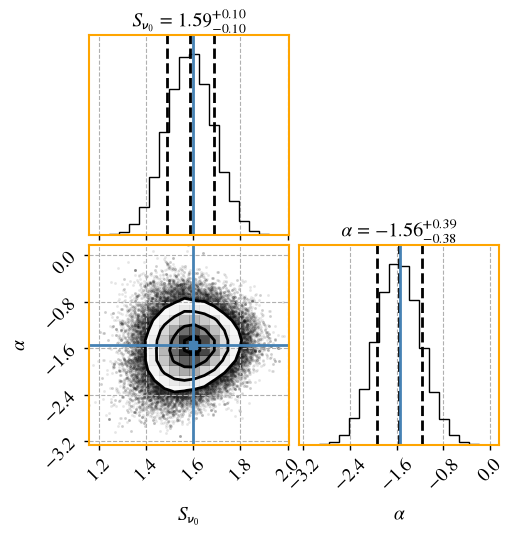

++==>> Parameter Results (MCMC sampling).
++==>> Parameter Results (from least-squares fit).
[[Variables]]
    A1:     1.60046424 +/- 0.03448562 (2.15%) (init = 1.600464)
    alpha: -1.53739621 +/- 0.13185482 (8.58%) (init = -1.537396)
[[Correlations]] (unreported correlations are < 0.100)
    C(A1, alpha) = 0.406
---------------------------------------------
------------ RESTORING BEAM SIZE ------------
                0.085 arcec            
---------------------------------------------


In [8]:
# prefix = f"im_nc{n_subimages}_cb"
robust = [1.0]
for vis_name in list(vis_list.keys()):
    print(f"Imaging instrument/band {vis_name}")
    print(f"    > Visibility: {vis_list[vis_name]}")
    for ROBUST in robust:
        image_list,image_statistics,Omaj = \
            mlibs.run_wsclean(vis_list[vis_name], robust=ROBUST,
                        imsize=imsizex, 
                        imsizey=imsizey, 
                        opt_args= opt_args,
                        cell=cell,
                        base_name=prefix,
                        nsigma_automask=nsigma_automask,
                        nsigma_autothreshold=nsigma_autothreshold,
                        quiet=True,
                        nc=n_subimages,
                        with_multiscale=True,
                        # scales='0,40,120,240',
                        scales='None',
                        datacolumn='DATA',
                        # datacolumn='CORRECTED_DATA',
                        calculate_subband_fluxes = True,
                        channel_division = 'default',
                        uvtaper=uvtaper,
                        niter=100000)


# Native combined imaging

In [9]:
n_subimages = 4
imsizex = int(1024*2)
imsizey = int(1024*2)
opt_args= "' -circular-beam '"
cell = '0.008asec'
# prefix = f"im_nc{n_subimages}_cb_bandwidth"
prefix = f"im_nc{n_subimages}_cb"
nsigma_automask = '4.0'
nsigma_autothreshold = '2.0'
uvtaper = ['']
vis_list = {
    'eM_VLA_C':   '/media/sagauga/void/astronomical-data/LIRGI_Sample_v2/IRAS23436+5257/eMERLIN_VLA_combined/C_band/concat_v2/IRAS23436+5257_C_2x_concat_wts.ms',
}
for image_name in vis_list.keys():
    print(image_name)
    print(vis_list[image_name])
    mlibs.listobs(vis=vis_list[image_name],listfile=vis_list[image_name].replace('.ms','.listobs'),overwrite=True)


eM_VLA_C
/media/sagauga/void/astronomical-data/LIRGI_Sample_v2/IRAS23436+5257/eMERLIN_VLA_combined/C_band/concat_v2/IRAS23436+5257_C_2x_concat_wts.ms


Imaging instrument/band eM_VLA_C
    > Visibility: /media/sagauga/void/astronomical-data/LIRGI_Sample_v2/IRAS23436+5257/eMERLIN_VLA_combined/C_band/concat_v2/IRAS23436+5257_C_2x_concat_wts.ms
 >> Imaging script path: /media/sagauga/starbyte/cloud/SACO/GitHub/morphen/morphen
 >> Using 24 threads for processing. Total threads available: 24
 >> Using WSClean container: /media/sagauga/starbyte/cloud/SACO/GitHub/morphen/morphen/wsclean36_cpu_portable_emerlin.sif (from ph4ser module directory)
Using WSClean from singularity image:  /media/sagauga/starbyte/cloud/SACO/GitHub/morphen/morphen/wsclean36_cpu_portable_emerlin.sif
WSClean version from singularity image: 

WSClean version 3.6 (2025-02-07)
Git commit hash: v3.6
This software package is released under the GPL version 3.
Author: André Offringa (offringa@gmail.com).

EveryBeam is available.
IDG is available.
WGridder is available.
  0.25
Using mtmfs method.
im_nc4_cb_IRAS23436+5257_C_2x_concat_wts_2048x2048_am_4.0_at_2.0_0.008asec_multis

/media/sagauga/starbyte/cloud/SACO/GitHub/morphen/morphen/image_morphometry.py:7382: RuntimeWarning: invalid value encountered in divide
  y0peak, x0peak = nd.maximum_position((image / rr2))


 ==>  Peak of Flux      = 0.640 +/- 0.041 [mJy/beam] (SNR=48.0)
 ==>  Snu (within mask) = 6.403 +/- 0.357 [mJy]
 ==>  Snu (image)       = 8.406 (no independent error estimate)
 ==>  R50               = 0.3017 +/- 0.0149 [arcsec]
 ==>  R50_major         = 0.3237 +/- 0.0160 [arcsec]  (q_eff=0.87)
 ==>  R95               = 0.5666 +/- 0.0417 [arcsec]
 ==>  R95_major         = 0.6079 +/- 0.0448 [arcsec]  (q_eff=0.87)


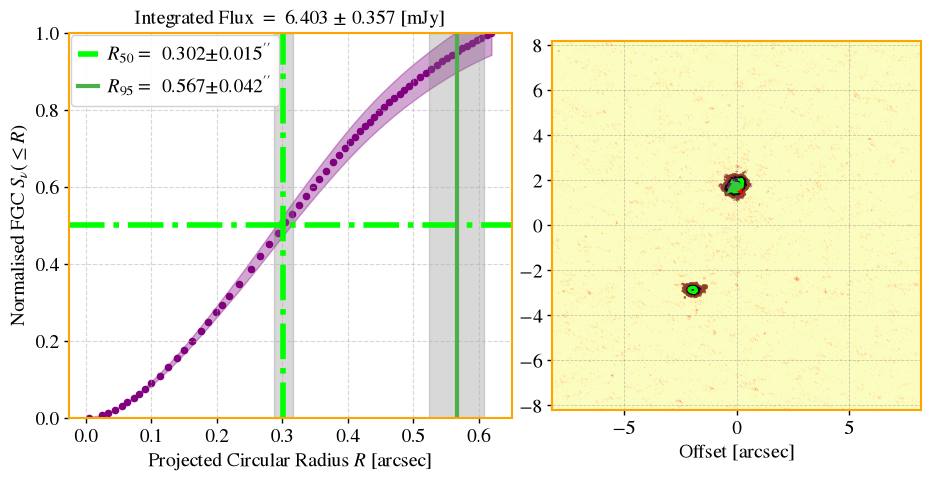

Using residual map as RMS estimator: /media/sagauga/void/astronomical-data/LIRGI_Sample_v2/IRAS23436+5257/eMERLIN_VLA_combined/C_band/concat_v2/im_nc4_cb_IRAS23436+5257_C_2x_concat_wts_2048x2048_am_4.0_at_2.0_0.008asec_multiscale__r0.25-MFS-residual.fits
-----------------------------------------------------------------
Flux Density (systematic + noise*sqrt(N_beams) + residual):
  S_nu = 7.090 +/- 0.381 mJy
  Fractional error = 0.054
-----------------------------------------------------------------


/media/sagauga/starbyte/cloud/SACO/GitHub/morphen/morphen/image_morphometry.py:7382: RuntimeWarning: invalid value encountered in divide
  y0peak, x0peak = nd.maximum_position((image / rr2))


 ==>  Peak of Flux      = 1.416 +/- 0.076 [mJy/beam] (SNR=53.3)
 ==>  Snu (within mask) = 7.090 +/- 0.381 [mJy]
 ==>  Snu (image)       = 9.194 (no independent error estimate)
 ==>  R50               = 0.3337 +/- 0.0141 [arcsec]
 ==>  R50_major         = 0.3585 +/- 0.0152 [arcsec]  (q_eff=0.87)
 ==>  R95               = 0.6344 +/- 0.0302 [arcsec]
 ==>  R95_major         = 0.6815 +/- 0.0325 [arcsec]  (q_eff=0.87)
-----------------------------------------------------------------
Flux Density (systematic + noise*sqrt(N_beams) + residual):
  S_nu = 5.533 +/- 0.488 mJy
  Fractional error = 0.088
-----------------------------------------------------------------


/media/sagauga/starbyte/cloud/SACO/GitHub/morphen/morphen/image_morphometry.py:7382: RuntimeWarning: invalid value encountered in divide
  y0peak, x0peak = nd.maximum_position((image / rr2))


 ==>  Peak of Flux      = 0.486 +/- 0.039 [mJy/beam] (SNR=16.3)
 ==>  Snu (within mask) = 5.533 +/- 0.488 [mJy]
 ==>  Snu (image)       = 7.724 (no independent error estimate)
 ==>  R50               = 0.2529 +/- 0.0439 [arcsec]
 ==>  R50_major         = 0.2775 +/- 0.0482 [arcsec]  (q_eff=0.83)
 ==>  R95               = 0.4202 +/- 0.0544 [arcsec]
 ==>  R95_major         = 0.4609 +/- 0.0597 [arcsec]  (q_eff=0.83)
-----------------------------------------------------------------
Flux Density (systematic + noise*sqrt(N_beams) + residual):
  S_nu = 6.777 +/- 0.437 mJy
  Fractional error = 0.064
-----------------------------------------------------------------


...

 ==>  Peak of Flux      = 0.744 +/- 0.064 [mJy/beam] (SNR=30.7)
 ==>  Snu (within mask) = 6.777 +/- 0.437 [mJy]
 ==>  Snu (image)       = 8.652 (no independent error estimate)
 ==>  R50               = 0.2845 +/- 0.0258 [arcsec]
 ==>  R50_major         = 0.3146 +/- 0.0285 [arcsec]  (q_eff=0.82)
 ==>  R95               = 0.5038 +/- 0.0532 [arcsec]
 ==>  R95_major         = 0.5571 +/- 0.0589 [arcsec]  (q_eff=0.82)
-----------------------------------------------------------------
Flux Density (systematic + noise*sqrt(N_beams) + residual):
  S_nu = 6.099 +/- 1.288 mJy
  Fractional error = 0.211
-----------------------------------------------------------------


/media/sagauga/starbyte/cloud/SACO/GitHub/morphen/morphen/image_morphometry.py:7382: RuntimeWarning: invalid value encountered in divide
  y0peak, x0peak = nd.maximum_position((image / rr2))


 ==>  Peak of Flux      = 0.375 +/- 0.063 [mJy/beam] (SNR=14.3)
 ==>  Snu (within mask) = 6.099 +/- 1.288 [mJy]
 ==>  Snu (image)       = 7.121 (no independent error estimate)
 ==>  R50               = 0.1782 +/- 0.0702 [arcsec]
 ==>  R50_major         = 0.1923 +/- 0.0757 [arcsec]  (q_eff=0.86)
 ==>  R95               = 0.2771 +/- 0.1114 [arcsec]
 ==>  R95_major         = 0.2991 +/- 0.1202 [arcsec]  (q_eff=0.86)
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         3.3985e+00                                    8.51e+00    
       1              3         8.0867e-01      2.59e+00       2.49e+00       7.92e+00    
       2              5         2.6129e-01      5.47e-01       6.03e-01       4.50e+00    
       3              6         3.9413e-02      2.22e-01       8.92e-01       1.28e+03    
       4              7         3.0692e-02      8.72e-03       1.49e-01       1.72e+00    
       5              8         3.0691

100%|██████████| 5000/5000 [00:03<00:00, 1442.36it/s]


{'A1': {'best': 6.131009973642877, 'lower_bound': 5.822224625835911, 'upper_bound': 6.425811823412729, 'lower': 0.30878534780696576, 'upper': 0.29480184976985147}, 'alpha': {'best': -0.7220451175996689, 'lower_bound': -1.026716100273084, 'upper_bound': -0.4359541222953283, 'lower': 0.3046709826734151, 'upper': 0.2860909953043406}}


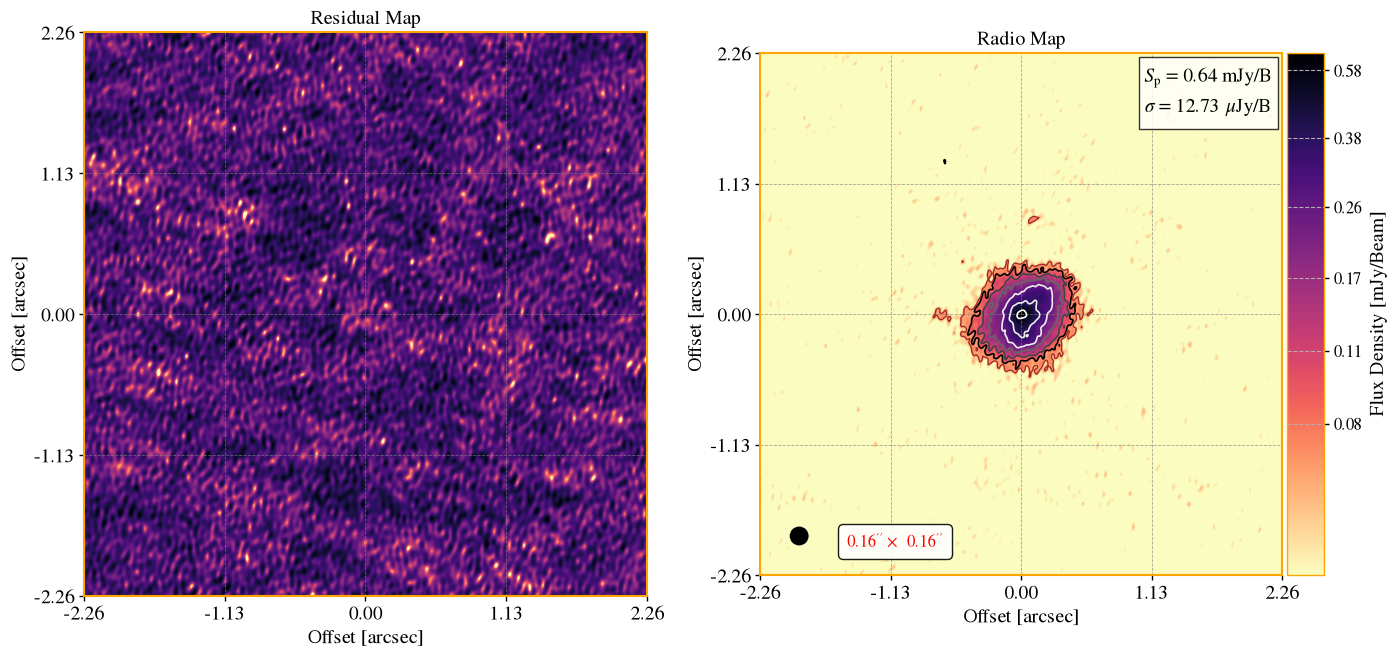

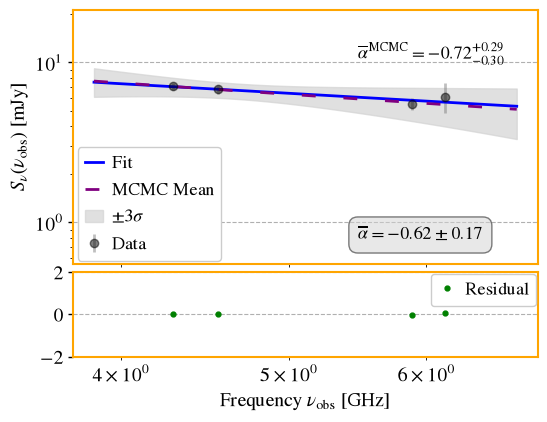

(100000, 2)


<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

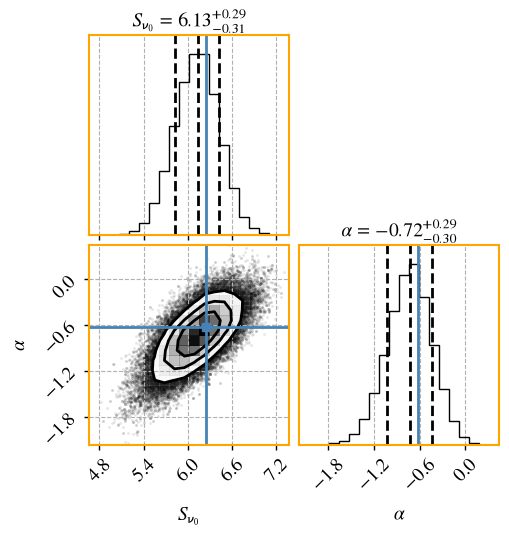

++==>> Parameter Results (MCMC sampling).
++==>> Parameter Results (from least-squares fit).
[[Variables]]
    A1:     6.24670845 +/- 0.17370567 (2.78%) (init = 6.246708)
    alpha: -0.61746406 +/- 0.17197400 (27.85%) (init = -0.6174641)
[[Correlations]] (unreported correlations are < 0.100)
    C(A1, alpha) = 0.472
---------------------------------------------
------------ RESTORING BEAM SIZE ------------
                0.164 arcec            
---------------------------------------------


In [10]:
# prefix = f"im_nc{n_subimages}_cb"
robust = [0.25]
for vis_name in list(vis_list.keys()):
    print(f"Imaging instrument/band {vis_name}")
    print(f"    > Visibility: {vis_list[vis_name]}")
    for ROBUST in robust:
        image_list,image_statistics,Omaj = \
            mlibs.run_wsclean(vis_list[vis_name], robust=ROBUST,
                        imsize=imsizex, 
                        imsizey=imsizey, 
                        opt_args= opt_args,
                        cell=cell,
                        base_name=prefix,
                        nsigma_automask=nsigma_automask,
                        nsigma_autothreshold=nsigma_autothreshold,
                        quiet=True,
                        nc=n_subimages,
                        with_multiscale=True,
                        # scales='0,40,120,240',
                        scales='None',
                        datacolumn='DATA',
                        # datacolumn='CORRECTED_DATA',
                        calculate_subband_fluxes = True,
                        channel_division = 'default',
                        uvtaper=uvtaper,
                        niter=100000)


# Native combined imaging with equalised channel weights

In [4]:
n_subimages = 4
imsizex = int(1024*2)
imsizey = int(1024*2)
opt_args= "' -circular-beam '"
cell = '0.008asec'
# prefix = f"im_nc{n_subimages}_cb_bandwidth"
prefix = f"im_nc{n_subimages}_cb"
nsigma_automask = '4.0'
nsigma_autothreshold = '2.0'
uvtaper = ['']
vis_list = {
    'eM_VLA_C':   '/media/sagauga/void/astronomical-data/LIRGI_Sample_v2/IRAS23436+5257/eMERLIN_VLA_combined/C_band/concat_v2/IRAS23436+5257_C_2x_concat_wts_bw_nc4.ms',
}
for image_name in vis_list.keys():
    print(image_name)
    print(vis_list[image_name])
    mlibs.listobs(vis=vis_list[image_name],listfile=vis_list[image_name].replace('.ms','.listobs'),overwrite=True)


eM_VLA_C
/media/sagauga/void/astronomical-data/LIRGI_Sample_v2/IRAS23436+5257/eMERLIN_VLA_combined/C_band/concat_v2/IRAS23436+5257_C_2x_concat_wts_bw_nc4.ms


Imaging instrument/band eM_VLA_C
    > Visibility: /media/sagauga/void/astronomical-data/LIRGI_Sample_v2/IRAS23436+5257/eMERLIN_VLA_combined/C_band/concat_v2/IRAS23436+5257_C_2x_concat_wts_bw_nc4.ms
 >> Imaging script path: /media/sagauga/starbyte/cloud/SACO/GitHub/morphen/morphen
 >> Using 24 threads for processing. Total threads available: 24
 >> Using WSClean container: /media/sagauga/starbyte/cloud/SACO/GitHub/morphen/morphen/wsclean36_cpu_portable_emerlin.sif (from ph4ser module directory)
Using WSClean from singularity image:  /media/sagauga/starbyte/cloud/SACO/GitHub/morphen/morphen/wsclean36_cpu_portable_emerlin.sif
WSClean version from singularity image: 

WSClean version 3.6 (2025-02-07)
Git commit hash: v3.6
This software package is released under the GPL version 3.
Author: André Offringa (offringa@gmail.com).

EveryBeam is available.
IDG is available.
WGridder is available.
  0.25
Using mtmfs method.
im_nc4_cb_IRAS23436+5257_C_2x_concat_wts_bw_nc4_2048x2048_am_4.0_at_2.0_0.

/media/sagauga/starbyte/cloud/SACO/GitHub/morphen/morphen/image_morphometry.py:7382: RuntimeWarning: invalid value encountered in divide
  y0peak, x0peak = nd.maximum_position((image / rr2))


 ==>  Peak of Flux      = 0.614 +/- 0.041 [mJy/beam] (SNR=40.5)
 ==>  Snu (within mask) = 6.374 +/- 0.347 [mJy]
 ==>  Snu (image)       = 8.603 (no independent error estimate)
 ==>  R50               = 0.2976 +/- 0.0184 [arcsec]
 ==>  R50_major         = 0.3216 +/- 0.0199 [arcsec]  (q_eff=0.86)
 ==>  R95               = 0.5452 +/- 0.0443 [arcsec]
 ==>  R95_major         = 0.5891 +/- 0.0479 [arcsec]  (q_eff=0.86)


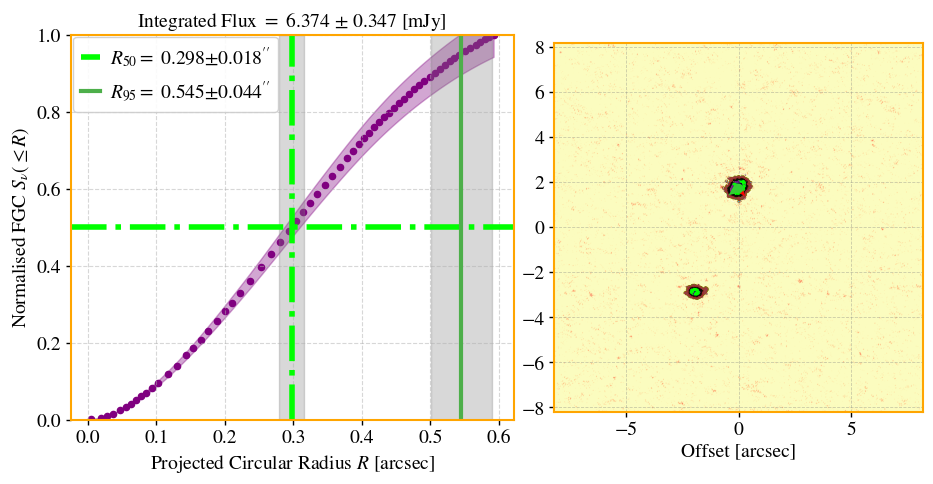

Using residual map as RMS estimator: /media/sagauga/void/astronomical-data/LIRGI_Sample_v2/IRAS23436+5257/eMERLIN_VLA_combined/C_band/concat_v2/im_nc4_cb_IRAS23436+5257_C_2x_concat_wts_bw_nc4_2048x2048_am_4.0_at_2.0_0.008asec_multiscale__r0.25-MFS-residual.fits
-----------------------------------------------------------------
Flux Density (systematic + noise*sqrt(N_beams) + residual):
  S_nu = 7.103 +/- 0.416 mJy
  Fractional error = 0.059
-----------------------------------------------------------------


/media/sagauga/starbyte/cloud/SACO/GitHub/morphen/morphen/image_morphometry.py:7382: RuntimeWarning: invalid value encountered in divide
  y0peak, x0peak = nd.maximum_position((image / rr2))


 ==>  Peak of Flux      = 0.775 +/- 0.051 [mJy/beam] (SNR=23.7)
 ==>  Snu (within mask) = 7.103 +/- 0.416 [mJy]
 ==>  Snu (image)       = 10.985 (no independent error estimate)
 ==>  R50               = 0.2824 +/- 0.0311 [arcsec]
 ==>  R50_major         = 0.3078 +/- 0.0339 [arcsec]  (q_eff=0.84)
 ==>  R95               = 0.4876 +/- 0.0575 [arcsec]
 ==>  R95_major         = 0.5314 +/- 0.0627 [arcsec]  (q_eff=0.84)
-----------------------------------------------------------------
Flux Density (systematic + noise*sqrt(N_beams) + residual):
  S_nu = 6.675 +/- 0.383 mJy
  Fractional error = 0.057
-----------------------------------------------------------------


/media/sagauga/starbyte/cloud/SACO/GitHub/morphen/morphen/image_morphometry.py:7382: RuntimeWarning: invalid value encountered in divide
  y0peak, x0peak = nd.maximum_position((image / rr2))


 ==>  Peak of Flux      = 0.716 +/- 0.063 [mJy/beam] (SNR=28.1)
 ==>  Snu (within mask) = 6.675 +/- 0.383 [mJy]
 ==>  Snu (image)       = 8.903 (no independent error estimate)
 ==>  R50               = 0.2820 +/- 0.0288 [arcsec]
 ==>  R50_major         = 0.3152 +/- 0.0322 [arcsec]  (q_eff=0.80)
 ==>  R95               = 0.4912 +/- 0.0487 [arcsec]
 ==>  R95_major         = 0.5490 +/- 0.0544 [arcsec]  (q_eff=0.80)
-----------------------------------------------------------------
Flux Density (systematic + noise*sqrt(N_beams) + residual):
  S_nu = 5.254 +/- 0.358 mJy
  Fractional error = 0.068
-----------------------------------------------------------------


...

 ==>  Peak of Flux      = 0.465 +/- 0.038 [mJy/beam] (SNR=15.6)
 ==>  Snu (within mask) = 5.254 +/- 0.358 [mJy]
 ==>  Snu (image)       = 8.046 (no independent error estimate)
 ==>  R50               = 0.2397 +/- 0.0479 [arcsec]
 ==>  R50_major         = 0.2653 +/- 0.0530 [arcsec]  (q_eff=0.82)
 ==>  R95               = 0.3915 +/- 0.0628 [arcsec]
 ==>  R95_major         = 0.4333 +/- 0.0695 [arcsec]  (q_eff=0.82)
-----------------------------------------------------------------
Flux Density (systematic + noise*sqrt(N_beams) + residual):
  S_nu = 5.247 +/- 0.390 mJy
  Fractional error = 0.074
-----------------------------------------------------------------


/media/sagauga/starbyte/cloud/SACO/GitHub/morphen/morphen/image_morphometry.py:7382: RuntimeWarning: invalid value encountered in divide
  y0peak, x0peak = nd.maximum_position((image / rr2))


 ==>  Peak of Flux      = 0.534 +/- 0.060 [mJy/beam] (SNR=17.7)
 ==>  Snu (within mask) = 5.247 +/- 0.390 [mJy]
 ==>  Snu (image)       = 6.061 (no independent error estimate)
 ==>  R50               = 0.2750 +/- 0.0407 [arcsec]
 ==>  R50_major         = 0.2984 +/- 0.0442 [arcsec]  (q_eff=0.85)
 ==>  R95               = 0.4601 +/- 0.0466 [arcsec]
 ==>  R95_major         = 0.4993 +/- 0.0506 [arcsec]  (q_eff=0.85)
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         3.8441e+00                                    8.51e+00    
       1              3         1.1887e+00      2.66e+00       2.50e+00       8.88e+00    
       2              5         1.7569e-01      1.01e+00       1.09e+00       3.21e+00    
       3              6         1.2004e-02      1.64e-01       7.23e-01       1.16e+03    
       4              7         3.7616e-03      8.24e-03       1.33e-01       9.17e-03    
       5              8         3.7587

100%|██████████| 5000/5000 [00:03<00:00, 1439.62it/s]


{'A1': {'best': 5.936813155125876, 'lower_bound': 5.7398268397037455, 'upper_bound': 6.134174456596189, 'lower': 0.19698631542213008, 'upper': 0.1973613014703135}, 'alpha': {'best': -0.8811823680159132, 'lower_bound': -1.0896363060834615, 'upper_bound': -0.6750888808534746, 'lower': 0.2084539380675483, 'upper': 0.20609348716243858}}


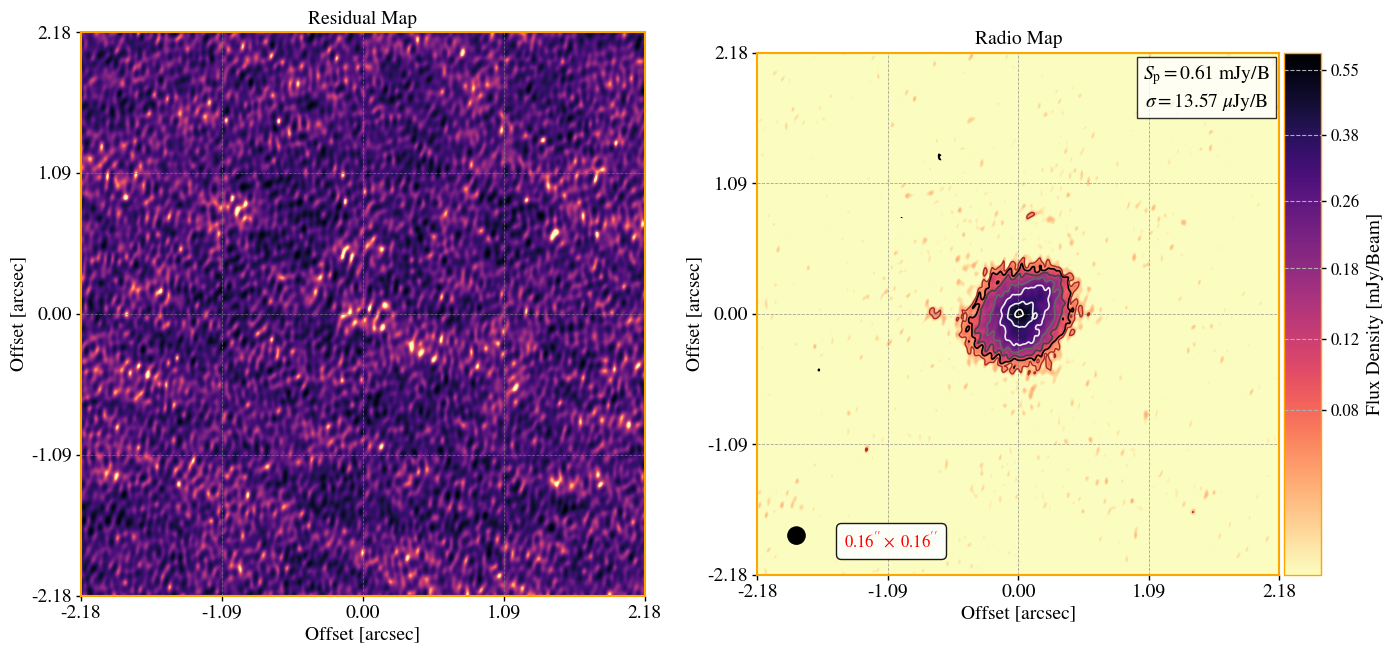

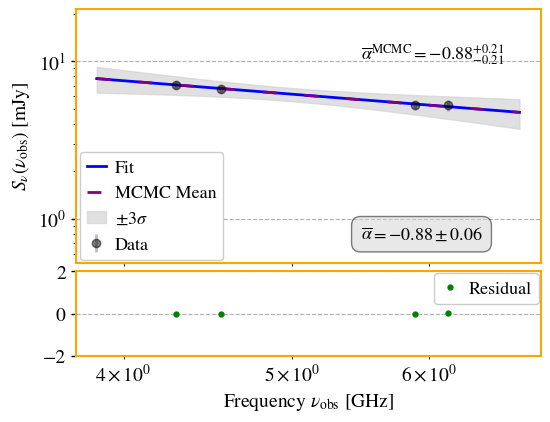

(100000, 2)


<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

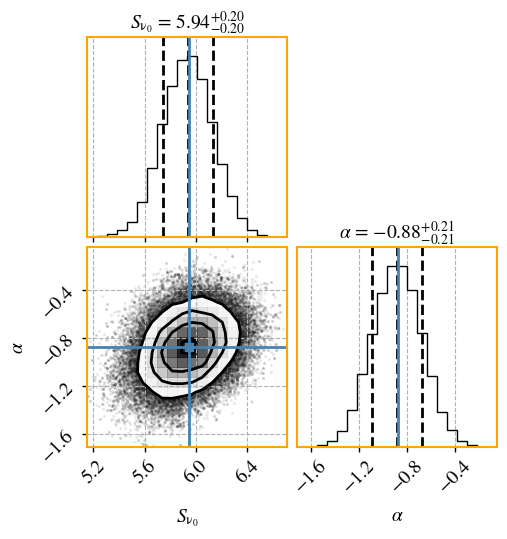

++==>> Parameter Results (MCMC sampling).
++==>> Parameter Results (from least-squares fit).
[[Variables]]
    A1:     5.94676166 +/- 0.05355566 (0.90%) (init = 5.946762)
    alpha: -0.87820559 +/- 0.05614355 (6.39%) (init = -0.8782056)
[[Correlations]] (unreported correlations are < 0.100)
    C(A1, alpha) = 0.324
---------------------------------------------
------------ RESTORING BEAM SIZE ------------
                0.155 arcec            
---------------------------------------------


In [6]:
# prefix = f"im_nc{n_subimages}_cb"
robust = [0.25]
for vis_name in list(vis_list.keys()):
    print(f"Imaging instrument/band {vis_name}")
    print(f"    > Visibility: {vis_list[vis_name]}")
    for ROBUST in robust:
        image_list,image_statistics,Omaj = \
            mlibs.run_wsclean(vis_list[vis_name], robust=ROBUST,
                        imsize=imsizex, 
                        imsizey=imsizey, 
                        opt_args= opt_args,
                        cell=cell,
                        base_name=prefix,
                        nsigma_automask=nsigma_automask,
                        nsigma_autothreshold=nsigma_autothreshold,
                        quiet=True,
                        nc=n_subimages,
                        with_multiscale=True,
                        # scales='0,40,120,240',
                        scales='None',
                        datacolumn='DATA',
                        # datacolumn='CORRECTED_DATA',
                        calculate_subband_fluxes = True,
                        channel_division = 'default',
                        uvtaper=uvtaper,
                        niter=100000)


# Native combined imaging --- forced restoring beam

In [11]:
n_subimages = 4
imsizex = int(1024*2)
imsizey = int(1024*2)
cell = '0.008asec'
restoring_beam_size = '0.08asec'
opt_args= f"' -circular-beam -beam-size {restoring_beam_size}'"
prefix = f"im_nc{n_subimages}_cb_bs_{restoring_beam_size}"
print(prefix)

nsigma_automask = '4.0'
nsigma_autothreshold = '2.0'
uvtaper = ['']
vis_list = {
    'eM_VLA_C':   '/media/sagauga/void/astronomical-data/LIRGI_Sample_v2/IRAS23436+5257/eMERLIN_VLA_combined/C_band/concat_v2/IRAS23436+5257_C_2x_concat_wts.ms',
}
for image_name in vis_list.keys():
    print(image_name)
    print(vis_list[image_name])
    mlibs.listobs(vis=vis_list[image_name],listfile=vis_list[image_name].replace('.ms','.listobs'),overwrite=True)

im_nc4_cb_bs_0.08asec
eM_VLA_C
/media/sagauga/void/astronomical-data/LIRGI_Sample_v2/IRAS23436+5257/eMERLIN_VLA_combined/C_band/concat_v2/IRAS23436+5257_C_2x_concat_wts.ms


Imaging instrument/band eM_VLA_C
    > Visibility: /media/sagauga/void/astronomical-data/LIRGI_Sample_v2/IRAS23436+5257/eMERLIN_VLA_combined/C_band/concat_v2/IRAS23436+5257_C_2x_concat_wts.ms
 >> Imaging script path: /media/sagauga/starbyte/cloud/SACO/GitHub/morphen/morphen
 >> Using 24 threads for processing. Total threads available: 24
 >> Using WSClean container: /media/sagauga/starbyte/cloud/SACO/GitHub/morphen/morphen/wsclean36_cpu_portable_emerlin.sif (from ph4ser module directory)
Using WSClean from singularity image:  /media/sagauga/starbyte/cloud/SACO/GitHub/morphen/morphen/wsclean36_cpu_portable_emerlin.sif
WSClean version from singularity image: 

WSClean version 3.6 (2025-02-07)
Git commit hash: v3.6
This software package is released under the GPL version 3.
Author: André Offringa (offringa@gmail.com).

EveryBeam is available.
IDG is available.
WGridder is available.
  0.25
Using mtmfs method.
im_nc4_cb_bs_0.08asec_IRAS23436+5257_C_2x_concat_wts_2048x2048_am_4.0_at_2.0_0.00

/media/sagauga/starbyte/cloud/SACO/GitHub/morphen/morphen/image_morphometry.py:7382: RuntimeWarning: invalid value encountered in divide
  y0peak, x0peak = nd.maximum_position((image / rr2))


 ==>  Peak of Flux      = 0.378 +/- 0.032 [mJy/beam] (SNR=25.9)
 ==>  Snu (within mask) = 4.722 +/- 0.284 [mJy]
 ==>  Snu (image)       = 14.910 (no independent error estimate)
 ==>  R50               = 0.2193 +/- 0.0661 [arcsec]
 ==>  R50_major         = 0.2587 +/- 0.0779 [arcsec]  (q_eff=0.72)
 ==>  R95               = 0.3523 +/- 0.0489 [arcsec]
 ==>  R95_major         = 0.4156 +/- 0.0577 [arcsec]  (q_eff=0.72)


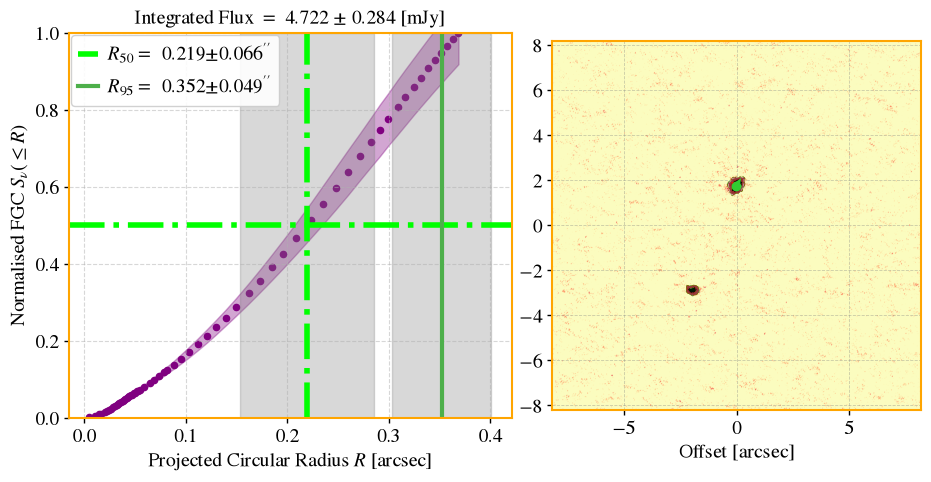

Using residual map as RMS estimator: /media/sagauga/void/astronomical-data/LIRGI_Sample_v2/IRAS23436+5257/eMERLIN_VLA_combined/C_band/concat_v2/im_nc4_cb_bs_0.08asec_IRAS23436+5257_C_2x_concat_wts_2048x2048_am_4.0_at_2.0_0.008asec_multiscale__r0.25-MFS-residual.fits
-----------------------------------------------------------------
Flux Density (systematic + noise*sqrt(N_beams) + residual):
  S_nu = 3.924 +/- 0.667 mJy
  Fractional error = 0.170
-----------------------------------------------------------------


/media/sagauga/starbyte/cloud/SACO/GitHub/morphen/morphen/image_morphometry.py:7382: RuntimeWarning: invalid value encountered in divide
  y0peak, x0peak = nd.maximum_position((image / rr2))


 ==>  Peak of Flux      = 0.433 +/- 0.056 [mJy/beam] (SNR=17.5)
 ==>  Snu (within mask) = 3.924 +/- 0.667 [mJy]
 ==>  Snu (image)       = 12.972 (no independent error estimate)
 ==>  R50               = 0.1419 +/- 0.0622 [arcsec]
 ==>  R50_major         = 0.1803 +/- 0.0790 [arcsec]  (q_eff=0.62)
 ==>  R95               = 0.2219 +/- 0.0852 [arcsec]
 ==>  R95_major         = 0.2820 +/- 0.1083 [arcsec]  (q_eff=0.62)
-----------------------------------------------------------------
Flux Density (systematic + noise*sqrt(N_beams) + residual):
  S_nu = 4.137 +/- 0.682 mJy
  Fractional error = 0.165
-----------------------------------------------------------------


/media/sagauga/starbyte/cloud/SACO/GitHub/morphen/morphen/image_morphometry.py:7382: RuntimeWarning: invalid value encountered in divide
  y0peak, x0peak = nd.maximum_position((image / rr2))


 ==>  Peak of Flux      = 0.418 +/- 0.034 [mJy/beam] (SNR=15.8)
 ==>  Snu (within mask) = 4.137 +/- 0.682 [mJy]
 ==>  Snu (image)       = 27.438 (no independent error estimate)
 ==>  R50               = 0.1307 +/- 0.0733 [arcsec]
 ==>  R50_major         = 0.1643 +/- 0.0922 [arcsec]  (q_eff=0.63)
 ==>  R95               = 0.2048 +/- 0.0831 [arcsec]
 ==>  R95_major         = 0.2576 +/- 0.1044 [arcsec]  (q_eff=0.63)
-----------------------------------------------------------------
Flux Density (systematic + noise*sqrt(N_beams) + residual):
  S_nu = 4.289 +/- 0.957 mJy
  Fractional error = 0.223
-----------------------------------------------------------------


...

 ==>  Peak of Flux      = 0.310 +/- 0.030 [mJy/beam] (SNR=12.6)
 ==>  Snu (within mask) = 4.289 +/- 0.957 [mJy]
 ==>  Snu (image)       = 12.811 (no independent error estimate)
 ==>  R50               = 0.1410 +/- 0.0695 [arcsec]
 ==>  R50_major         = 0.1682 +/- 0.0829 [arcsec]  (q_eff=0.70)
 ==>  R95               = 0.2153 +/- 0.0946 [arcsec]
 ==>  R95_major         = 0.2568 +/- 0.1128 [arcsec]  (q_eff=0.70)
-----------------------------------------------------------------
Flux Density (systematic + noise*sqrt(N_beams) + residual):
  S_nu = 4.051 +/- 0.946 mJy
  Fractional error = 0.233
-----------------------------------------------------------------


/media/sagauga/starbyte/cloud/SACO/GitHub/morphen/morphen/image_morphometry.py:7382: RuntimeWarning: invalid value encountered in divide
  y0peak, x0peak = nd.maximum_position((image / rr2))


 ==>  Peak of Flux      = 0.347 +/- 0.063 [mJy/beam] (SNR=12.9)
 ==>  Snu (within mask) = 4.051 +/- 0.946 [mJy]
 ==>  Snu (image)       = 7.858 (no independent error estimate)
 ==>  R50               = 0.1359 +/- 0.0691 [arcsec]
 ==>  R50_major         = 0.1633 +/- 0.0830 [arcsec]  (q_eff=0.69)
 ==>  R95               = 0.2088 +/- 0.0740 [arcsec]
 ==>  R95_major         = 0.2509 +/- 0.0890 [arcsec]  (q_eff=0.69)
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         5.2061e+00                                    6.31e+00    
       1              2         3.5268e+00      1.68e+00       9.83e+00       8.95e+03    
       2              6         1.0046e+00      2.52e+00       4.95e+00       4.49e+00    
       3              7         9.0118e-01      1.03e-01       1.15e-01       4.29e+00    
       4              8         7.0136e-01      2.00e-01       2.28e-01       3.87e+00    
       5              9         3.4901

100%|██████████| 5000/5000 [00:03<00:00, 1486.18it/s]


{'A1': {'best': 4.035568038851389, 'lower_bound': 3.614013038583535, 'upper_bound': 4.450196696036058, 'lower': 0.4215550002678543, 'upper': 0.4146286571846689}, 'alpha': {'best': 0.05668396121097896, 'lower_bound': -0.5978774171063695, 'upper_bound': 0.6856662755317553, 'lower': 0.6545613783173485, 'upper': 0.6289823143207763}}


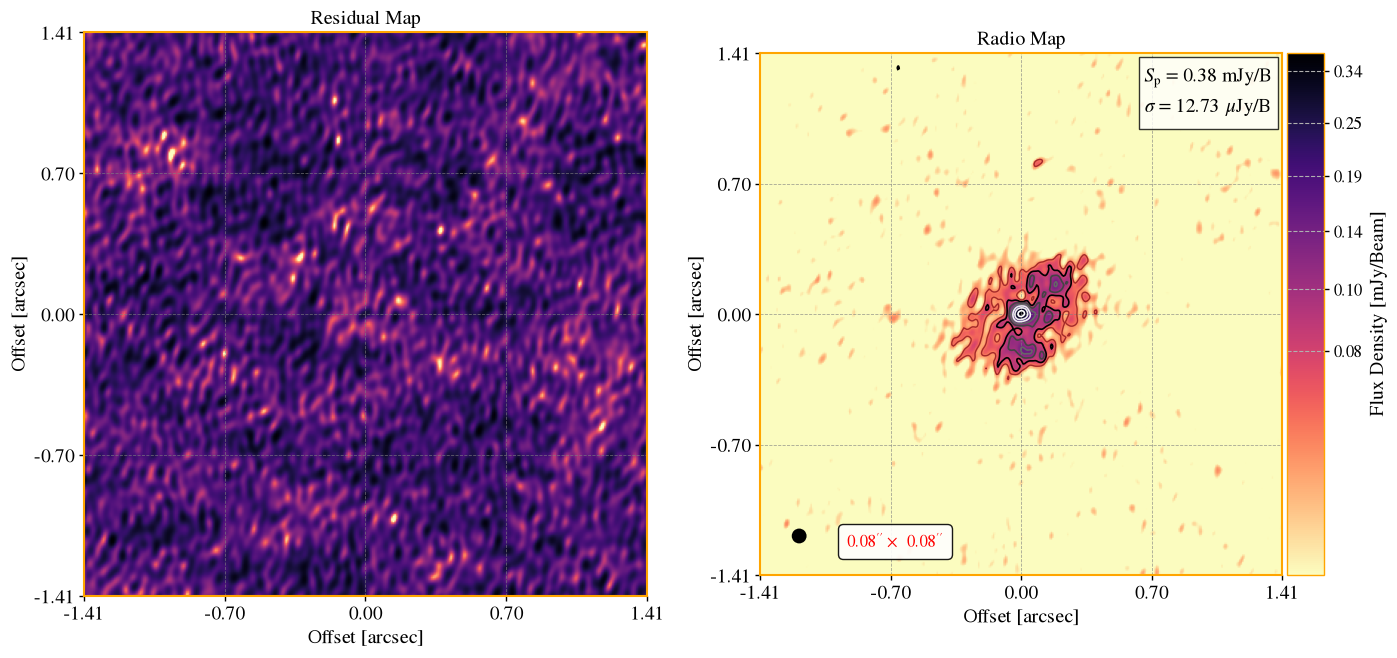

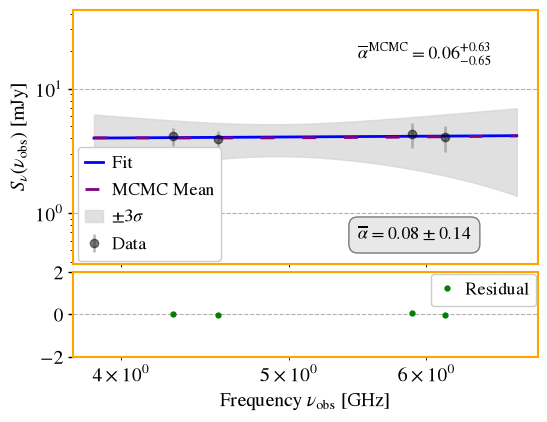

(100000, 2)


<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

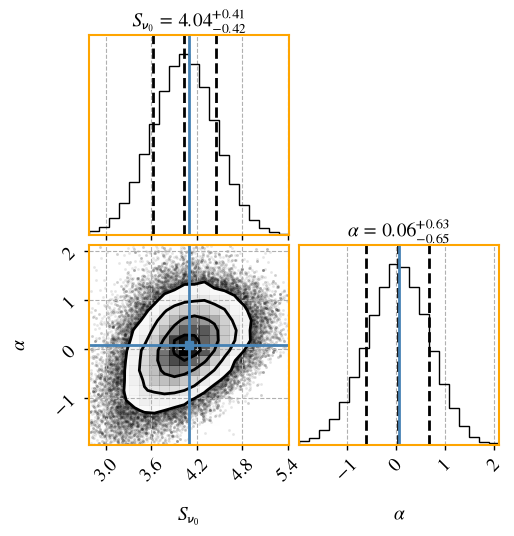

++==>> Parameter Results (MCMC sampling).
++==>> Parameter Results (from least-squares fit).
[[Variables]]
    A1:     4.10118076 +/- 0.08814938 (2.15%) (init = 4.101181)
    alpha:  0.07817173 +/- 0.13587475 (173.82%) (init = 0.07817174)
[[Correlations]] (unreported correlations are < 0.100)
    C(A1, alpha) = 0.151
---------------------------------------------
------------ RESTORING BEAM SIZE ------------
                0.080 arcec            
---------------------------------------------


In [12]:
robust = [0.25]
for vis_name in list(vis_list.keys()):
    print(f"Imaging instrument/band {vis_name}")
    print(f"    > Visibility: {vis_list[vis_name]}")
    for ROBUST in robust:
        image_list,image_statistics,Omaj = \
            mlibs.run_wsclean(vis_list[vis_name], robust=ROBUST,
                        imsize=imsizex, 
                        imsizey=imsizey, 
                        opt_args= opt_args,
                        cell=cell,
                        base_name=prefix,
                        nsigma_automask=nsigma_automask,
                        nsigma_autothreshold=nsigma_autothreshold,
                        quiet=True,
                        nc=n_subimages,
                        with_multiscale=True,
                        # scales='0,40,120,240',
                        scales='None',
                        datacolumn='DATA',
                        channel_division = 'default',
                        uvtaper=uvtaper,
                        niter=100000)


# Native combined imaging --- forced restoring beam and equalised channel weights

In [13]:
n_subimages = 4
imsizex = int(1024*2)
imsizey = int(1024*2)
cell = '0.008asec'
restoring_beam_size = '0.08asec'
opt_args= f"' -circular-beam -beam-size {restoring_beam_size}'"
prefix = f"im_nc{n_subimages}_cb_bs_{restoring_beam_size}"
print(prefix)

nsigma_automask = '4.0'
nsigma_autothreshold = '2.0'
uvtaper = ['']
vis_list = {
    # 'eM_VLA_C':   '/media/sagauga/void/astronomical-data/LIRGI_Sample_v2/IRAS23436+5257/eMERLIN_VLA_combined/C_band/concat_v2/IRAS23436+5257_C_2x_concat_wts.ms',
    'eM_VLA_C':   '/media/sagauga/void/astronomical-data/LIRGI_Sample_v2/IRAS23436+5257/eMERLIN_VLA_combined/C_band/concat_v2/IRAS23436+5257_C_2x_concat_wts_bw_nc4.ms',
}
for image_name in vis_list.keys():
    print(image_name)
    print(vis_list[image_name])
    mlibs.listobs(vis=vis_list[image_name],listfile=vis_list[image_name].replace('.ms','.listobs'),overwrite=True)

im_nc4_cb_bs_0.08asec
eM_VLA_C
/media/sagauga/void/astronomical-data/LIRGI_Sample_v2/IRAS23436+5257/eMERLIN_VLA_combined/C_band/concat_v2/IRAS23436+5257_C_2x_concat_wts_bw_nc4.ms


Imaging instrument/band eM_VLA_C
    > Visibility: /media/sagauga/void/astronomical-data/LIRGI_Sample_v2/IRAS23436+5257/eMERLIN_VLA_combined/C_band/concat_v2/IRAS23436+5257_C_2x_concat_wts_bw_nc4.ms
 >> Imaging script path: /media/sagauga/starbyte/cloud/SACO/GitHub/morphen/morphen
 >> Using 24 threads for processing. Total threads available: 24
 >> Using WSClean container: /media/sagauga/starbyte/cloud/SACO/GitHub/morphen/morphen/wsclean36_cpu_portable_emerlin.sif (from ph4ser module directory)
Using WSClean from singularity image:  /media/sagauga/starbyte/cloud/SACO/GitHub/morphen/morphen/wsclean36_cpu_portable_emerlin.sif
WSClean version from singularity image: 

WSClean version 3.6 (2025-02-07)
Git commit hash: v3.6
This software package is released under the GPL version 3.
Author: André Offringa (offringa@gmail.com).

EveryBeam is available.
IDG is available.
WGridder is available.
  0.25
Using mtmfs method.
im_nc4_cb_bs_0.08asec_IRAS23436+5257_C_2x_concat_wts_bw_nc4_2048x2048_am_4

/media/sagauga/starbyte/cloud/SACO/GitHub/morphen/morphen/image_morphometry.py:7382: RuntimeWarning: invalid value encountered in divide
  y0peak, x0peak = nd.maximum_position((image / rr2))


 ==>  Peak of Flux      = 0.376 +/- 0.033 [mJy/beam] (SNR=20.9)
 ==>  Snu (within mask) = 4.469 +/- 0.260 [mJy]
 ==>  Snu (image)       = 14.478 (no independent error estimate)
 ==>  R50               = 0.2124 +/- 0.0723 [arcsec]
 ==>  R50_major         = 0.2647 +/- 0.0901 [arcsec]  (q_eff=0.64)
 ==>  R95               = 0.3380 +/- 0.0516 [arcsec]
 ==>  R95_major         = 0.4213 +/- 0.0643 [arcsec]  (q_eff=0.64)


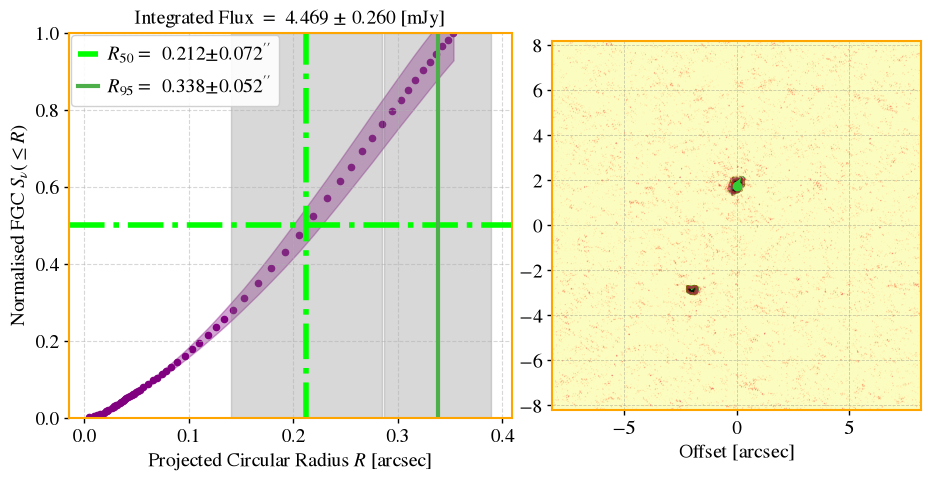

Using residual map as RMS estimator: /media/sagauga/void/astronomical-data/LIRGI_Sample_v2/IRAS23436+5257/eMERLIN_VLA_combined/C_band/concat_v2/im_nc4_cb_bs_0.08asec_IRAS23436+5257_C_2x_concat_wts_bw_nc4_2048x2048_am_4.0_at_2.0_0.008asec_multiscale__r0.25-MFS-residual.fits
-----------------------------------------------------------------
Flux Density (systematic + noise*sqrt(N_beams) + residual):
  S_nu = 4.013 +/- 0.424 mJy
  Fractional error = 0.106
-----------------------------------------------------------------


/media/sagauga/starbyte/cloud/SACO/GitHub/morphen/morphen/image_morphometry.py:7382: RuntimeWarning: invalid value encountered in divide
  y0peak, x0peak = nd.maximum_position((image / rr2))


 ==>  Peak of Flux      = 0.443 +/- 0.040 [mJy/beam] (SNR=13.7)
 ==>  Snu (within mask) = 4.013 +/- 0.424 [mJy]
 ==>  Snu (image)       = 23.105 (no independent error estimate)
 ==>  R50               = 0.1125 +/- 0.0507 [arcsec]
 ==>  R50_major         = 0.1476 +/- 0.0665 [arcsec]  (q_eff=0.58)
 ==>  R95               = 0.1758 +/- 0.0867 [arcsec]
 ==>  R95_major         = 0.2306 +/- 0.1137 [arcsec]  (q_eff=0.58)
-----------------------------------------------------------------
Flux Density (systematic + noise*sqrt(N_beams) + residual):
  S_nu = 3.863 +/- 0.351 mJy
  Fractional error = 0.091
-----------------------------------------------------------------


/media/sagauga/starbyte/cloud/SACO/GitHub/morphen/morphen/image_morphometry.py:7382: RuntimeWarning: invalid value encountered in divide
  y0peak, x0peak = nd.maximum_position((image / rr2))


 ==>  Peak of Flux      = 0.441 +/- 0.056 [mJy/beam] (SNR=15.3)
 ==>  Snu (within mask) = 3.863 +/- 0.351 [mJy]
 ==>  Snu (image)       = 13.801 (no independent error estimate)
 ==>  R50               = 0.1437 +/- 0.0733 [arcsec]
 ==>  R50_major         = 0.1903 +/- 0.0971 [arcsec]  (q_eff=0.57)
 ==>  R95               = 0.2247 +/- 0.0844 [arcsec]
 ==>  R95_major         = 0.2975 +/- 0.1117 [arcsec]  (q_eff=0.57)
-----------------------------------------------------------------
Flux Density (systematic + noise*sqrt(N_beams) + residual):
  S_nu = 3.558 +/- 0.453 mJy
  Fractional error = 0.127
-----------------------------------------------------------------


...

 ==>  Peak of Flux      = 0.299 +/- 0.033 [mJy/beam] (SNR=10.3)
 ==>  Snu (within mask) = 3.558 +/- 0.453 [mJy]
 ==>  Snu (image)       = 12.713 (no independent error estimate)
 ==>  R50               = 0.1121 +/- 0.0537 [arcsec]
 ==>  R50_major         = 0.1429 +/- 0.0685 [arcsec]  (q_eff=0.62)
 ==>  R95               = 0.1700 +/- 0.0956 [arcsec]
 ==>  R95_major         = 0.2167 +/- 0.1219 [arcsec]  (q_eff=0.62)
-----------------------------------------------------------------
Flux Density (systematic + noise*sqrt(N_beams) + residual):
  S_nu = 3.451 +/- 0.459 mJy
  Fractional error = 0.133
-----------------------------------------------------------------


/media/sagauga/starbyte/cloud/SACO/GitHub/morphen/morphen/image_morphometry.py:7382: RuntimeWarning: invalid value encountered in divide
  y0peak, x0peak = nd.maximum_position((image / rr2))


 ==>  Peak of Flux      = 0.312 +/- 0.044 [mJy/beam] (SNR=11.9)
 ==>  Snu (within mask) = 3.451 +/- 0.459 [mJy]
 ==>  Snu (image)       = 8.205 (no independent error estimate)
 ==>  R50               = 0.1339 +/- 0.0713 [arcsec]
 ==>  R50_major         = 0.1706 +/- 0.0908 [arcsec]  (q_eff=0.62)
 ==>  R95               = 0.2042 +/- 0.0727 [arcsec]
 ==>  R95_major         = 0.2602 +/- 0.0927 [arcsec]  (q_eff=0.62)
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         5.4933e+00                                    5.97e+00    
       1              2         2.8981e+00      2.60e+00       9.68e+00       1.05e+04    
       2              7         7.9784e-01      2.10e+00       2.47e+00       2.61e+00    
       3              8         7.4516e-01      5.27e-02       1.19e-01       5.06e+02    
       4              9         6.3153e-01      1.14e-01       2.85e-01       3.30e+02    
       5             10         4.0255

100%|██████████| 5000/5000 [00:02<00:00, 1683.81it/s]


{'A1': {'best': 3.6871800455044283, 'lower_bound': 3.5194866510123095, 'upper_bound': 3.8605502877171904, 'lower': 0.16769339449211884, 'upper': 0.1733702422127621}, 'alpha': {'best': -0.37571959412757244, 'lower_bound': -0.6632740007687256, 'upper_bound': -0.09119794014815068, 'lower': 0.2875544066411531, 'upper': 0.28452165397942175}}


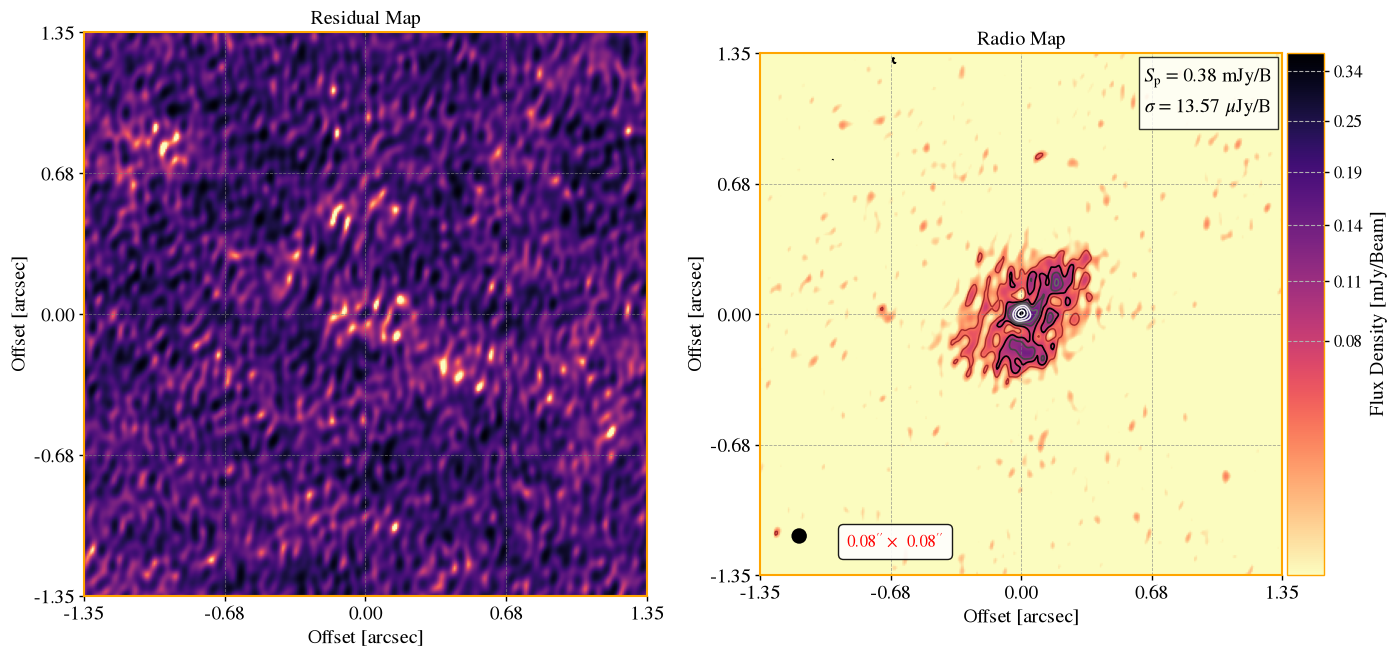

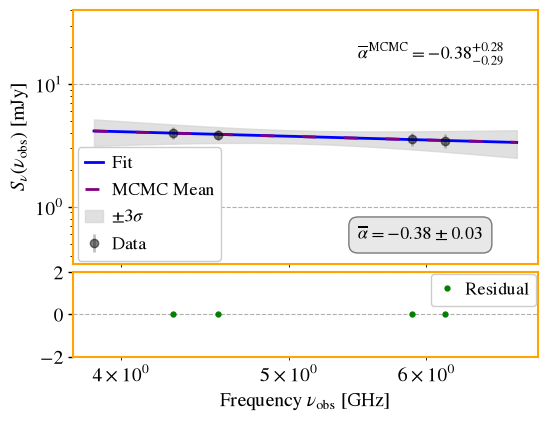

(100000, 2)


<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

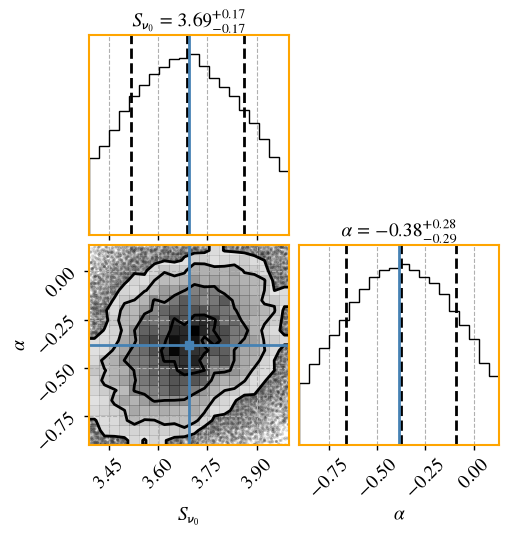

++==>> Parameter Results (MCMC sampling).
++==>> Parameter Results (from least-squares fit).
[[Variables]]
    A1:     3.69586216 +/- 0.02025672 (0.55%) (init = 3.695862)
    alpha: -0.38406125 +/- 0.03456314 (9.00%) (init = -0.3840612)
[[Correlations]] (unreported correlations are < 0.100)
    C(A1, alpha) = 0.236
---------------------------------------------
------------ RESTORING BEAM SIZE ------------
                0.080 arcec            
---------------------------------------------


In [14]:
robust = [0.25]
for vis_name in list(vis_list.keys()):
    print(f"Imaging instrument/band {vis_name}")
    print(f"    > Visibility: {vis_list[vis_name]}")
    for ROBUST in robust:
        image_list,image_statistics,Omaj = \
            mlibs.run_wsclean(vis_list[vis_name], robust=ROBUST,
                        imsize=imsizex, 
                        imsizey=imsizey, 
                        opt_args= opt_args,
                        cell=cell,
                        base_name=prefix,
                        nsigma_automask=nsigma_automask,
                        nsigma_autothreshold=nsigma_autothreshold,
                        quiet=True,
                        nc=n_subimages,
                        with_multiscale=True,
                        # scales='0,40,120,240',
                        scales='None',
                        datacolumn='DATA',
                        channel_division = 'default',
                        uvtaper=uvtaper,
                        niter=100000)
